# UCI Adult Income

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/UCI_Income.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1. The target variable is income. I think that it could be converted to a binary variable 0 for <=50k and 1 for >50k
2. The unit of prediction is a person/adult with a job
3. There doesn't seem to be leakage risks in the dataset. I don't know what the columns 'fnlwgt', 'education-num', 'capital-gain' and 'capital-loss' stand for and can't find the description of them on the website
4. The business-style cost of errors depends on the context we will apply this ML solution. If for example we are developing this solution for a consultancy agency that advices people on the salary they might expect I would say that we care more about false negatives since asking for a higher salary at a job interview might not have the same effect as agreeing on a lower salary. But if we were advising companies on the salary they should propose to candidates we might care more about false positives since that would cost the company and would result in some possible losses.

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [5]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked',
       nan], dtype=object)

In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [8]:
df['education'].unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [9]:
df_by_education = df.groupby('education')['education'].value_counts().reset_index()

In [10]:
df_by_education = df_by_education.sort_values(by='count')

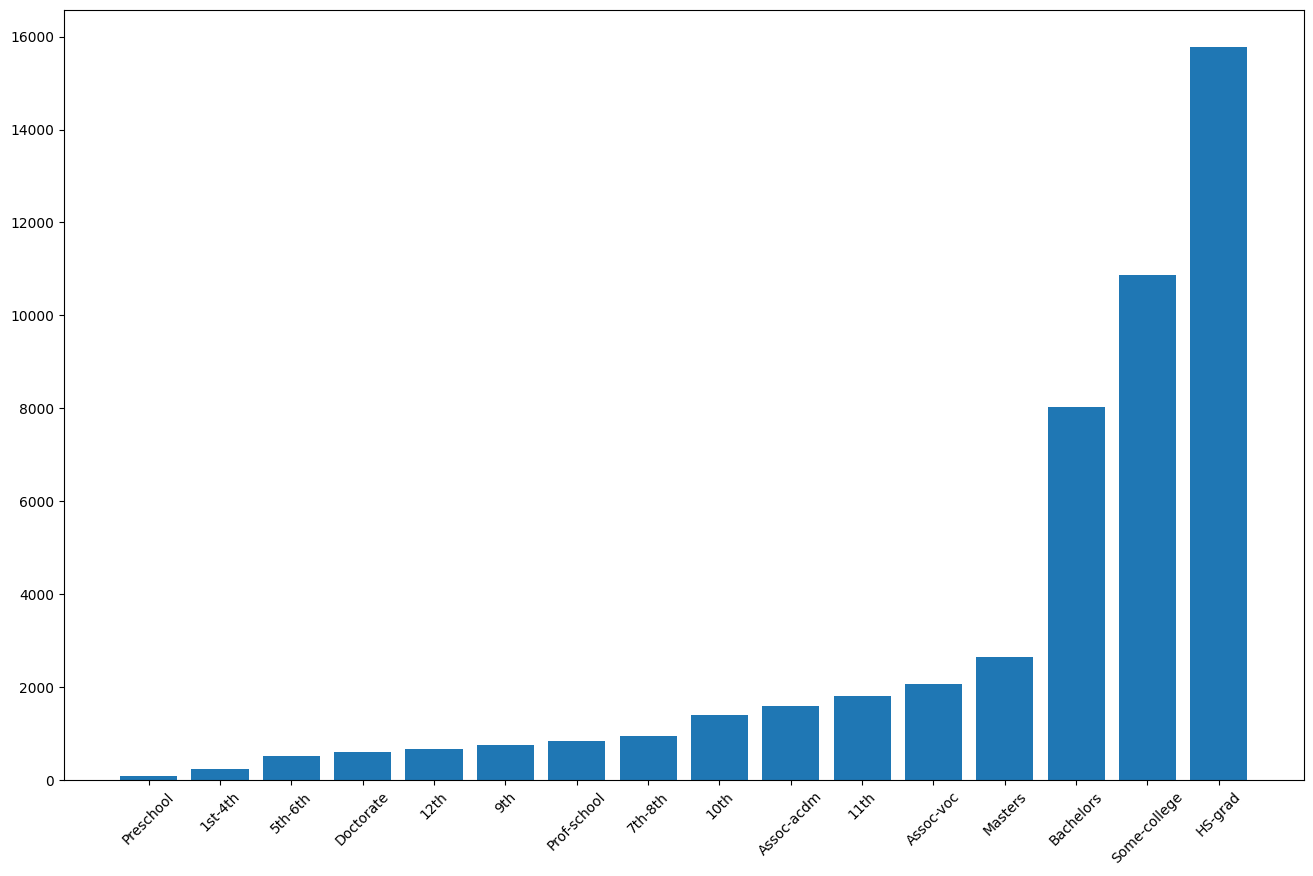

In [11]:
x = df_by_education['education']
y = df_by_education['count']

fig, ax = plt.subplots(figsize=(16,10))
ax.bar(x,y)
plt.xticks(rotation=45)
plt.show()

In [12]:
df['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

Some values of income have a '.' at the end I will assume that this is a typing mistake since I can't find an explanation of why this would be the case and don't have a way of confirming it

In [13]:
df['income'] = df['income'].map({'<=50K':0, '>50K':1, '<=50K.':0, '>50K.':1})

In [14]:
df_income_education = pd.crosstab(df['education'], df['income'], normalize='index').reset_index()

In [15]:
df_income_education = df_income_education.sort_values(by = 1)

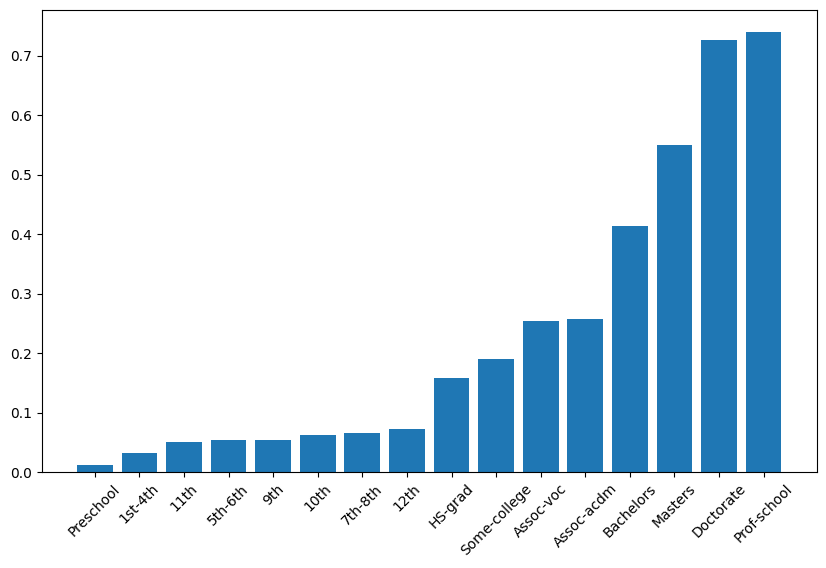

In [16]:
x = df_income_education['education']
y = df_income_education[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
plt.xticks(rotation=45)
plt.show()

In [17]:
df_income_education_num = pd.crosstab(df['education-num'], df['income'], normalize='index').reset_index()

In [18]:
df_income_education_num = df_income_education_num.sort_values(by = 1)

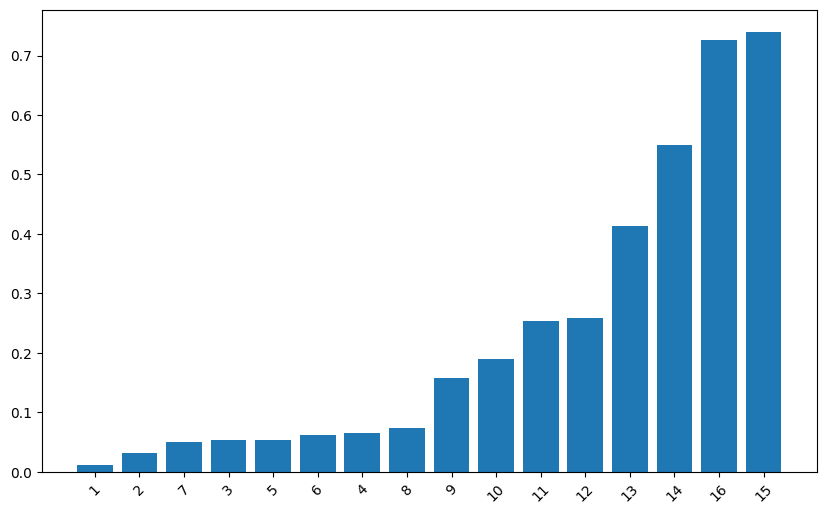

In [19]:
x = df_income_education_num['education-num'].astype(str)
y = df_income_education_num[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)

plt.xticks(rotation=45)
plt.show()

Looking at the plots and numbers I can safely assume that education and education-num are the same so it would be safe to drop one in the future

In [20]:
df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv', nan], dtype=object)

In [21]:
df_by_income = df['income'].value_counts(normalize=True).reset_index()

In [22]:
df_by_income

,income,proportion
0,0,0.760718
1,1,0.239282


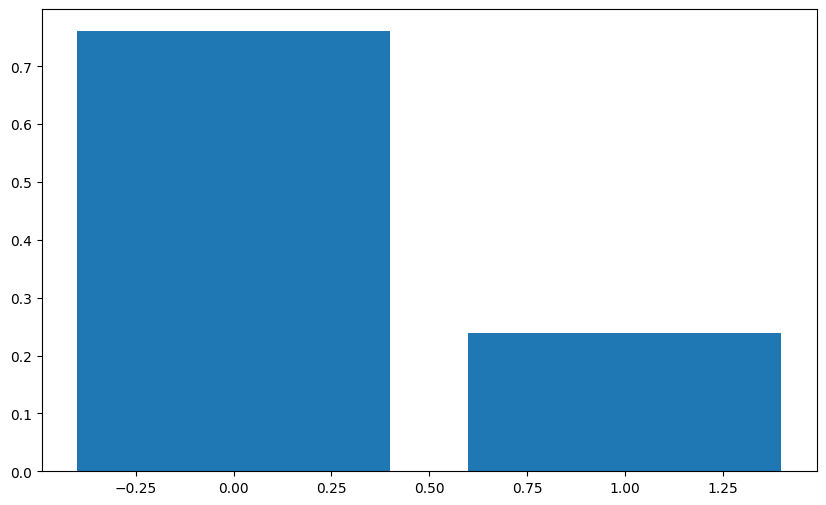

In [23]:
x = df_by_income['income']
y = df_by_income['proportion']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
plt.show()

In [24]:
df_ml = df[['age', 'workclass', 'education', 'occupation', 'income']]

In [25]:
df_ml

,age,workclass,education,occupation,income
0,39,State-gov,Bachelors,Adm-clerical,0
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,0
2,38,Private,HS-grad,Handlers-cleaners,0
3,53,Private,11th,Handlers-cleaners,0
4,28,Private,Bachelors,Prof-specialty,0
...,...,...,...,...,...
48837,39,Private,Bachelors,Prof-specialty,0
48838,64,NaN,HS-grad,NaN,0
48839,38,Private,Bachelors,Prof-specialty,0
48840,44,Private,Bachelors,Adm-clerical,0


In [26]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         48842 non-null  int64 
 1   workclass   47879 non-null  object
 2   education   48842 non-null  object
 3   occupation  47876 non-null  object
 4   income      48842 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.9+ MB


In [27]:
df_ml[(df_ml['workclass'].isna()) & (df_ml['income']==1)]

,age,workclass,education,occupation,income
32650,41,NaN,Masters,NaN,1
32743,28,NaN,HS-grad,NaN,1
32835,53,NaN,HS-grad,NaN,1
33066,38,NaN,HS-grad,NaN,1
33342,62,NaN,HS-grad,NaN,1
...,...,...,...,...,...
48085,46,NaN,Masters,NaN,1
48293,48,NaN,HS-grad,NaN,1
48397,42,NaN,Bachelors,NaN,1
48473,68,NaN,Some-college,NaN,1


In [28]:
df_ml[(df_ml['workclass'].isna()) & (df_ml['income']==0)]

,age,workclass,education,occupation,income
32565,18,NaN,Some-college,NaN,0
32567,29,NaN,HS-grad,NaN,0
32574,58,NaN,HS-grad,NaN,0
32583,72,NaN,7th-8th,NaN,0
32596,65,NaN,HS-grad,NaN,0
...,...,...,...,...,...
48682,61,NaN,Some-college,NaN,0
48769,21,NaN,Some-college,NaN,0
48800,73,NaN,HS-grad,NaN,0
48812,81,NaN,Assoc-voc,NaN,0


There are 963 rows with missing workclass

In [29]:
df_ml[(df_ml['workclass'].isna()) & (df_ml['occupation'].notna())]

,age,workclass,education,occupation,income


In [30]:
df_ml[(df_ml['occupation'].isna()) & (df_ml['workclass'].notna())]

,age,workclass,education,occupation,income
41346,17,Never-worked,11th,NaN,0
44168,20,Never-worked,HS-grad,NaN,0
46459,18,Never-worked,11th,NaN,0


All rows that don't have a value for workclass also don't have a value ofr occupation but there are 3 rows where there are values for workclass but none for occupation

In [31]:
df_ml = df_ml.dropna(subset=['occupation'])

In [32]:
df_ml = pd.get_dummies(df_ml, columns=['occupation','workclass','education'], drop_first=True)

In [33]:
df_ml.head(1)

,age,income,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,...,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college
0,39,0,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [35]:
x = df_ml.drop(columns=['income'])
y = df_ml['income']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.7920843776106934

In [37]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(x_test)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
specificity = recall_score(y_test,y_pred,pos_label=0)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.6308186195826645
Recall: 0.33923176521363835
Specificity: 0.9366303898608623


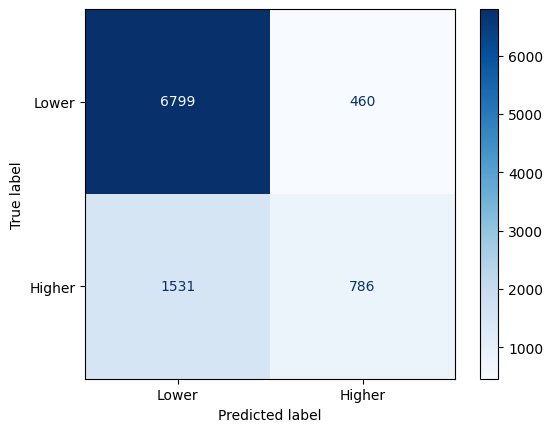

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

cmd.from_estimator(model,x_test,y_test,display_labels=['Lower','Higher'],cmap='Blues')

In [39]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.7788220551378446

In [40]:
y_pred = model.predict(x_test)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
specificity = recall_score(y_test,y_pred,pos_label=0)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.5610055180870631
Recall: 0.3949072075960294
Specificity: 0.9013638242182119


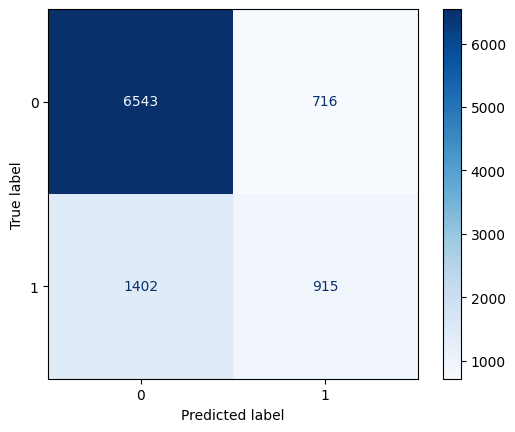

In [41]:
cmd.from_estimator(model, x_test, y_test, cmap='Blues')

1. FP - increased  and FN - decreased
2. Recall improved at the cost of specificity
3. We didn't define a business framing yet so you could specify it for me
4. Since I would like to find a job and not be underpayed I would trust the second model more since I would rather ask for a higher salary than settle for a lower one if I could try to get a higher one. If my interpretation of the results of the model this should be the second.

In [42]:
y_prob = model.predict_proba(x_test)[:,1]

In [43]:
for threshold in [0.3,0.5,0.7]:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    precision = precision_score(y_test,y_pred_thresh)
    recall = recall_score(y_test,y_pred_thresh)
    specificity = recall_score(y_test,y_pred_thresh,pos_label=0)

    print(f'\nThreshold: {threshold}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'Specificity: {specificity}')


Threshold: 0.3
Precision: 0.4613941856830259
Recall: 0.6370306430729391
Specificity: 0.7626394820223171

Threshold: 0.5
Precision: 0.5155741515574152
Recall: 0.4786361674579197
Specificity: 0.8564540570326491

Threshold: 0.7
Precision: 0.571150097465887
Recall: 0.25291324989210184
Specificity: 0.9393855903016944


### Computing ROC

ROC answers one question: "If I slide the decision threshold from 0 to 1, how does my model trade off catching positives (recall) and falsely flagging negatives (false positives)" ROC is not a metric, it is a curve that summarizes all possible thresholds. X-axis represents the False Positive Rate (FPR) and the Y-axis represents the True Positive Rate (TPR) = Recall. So every point on the curve is: "At threshold = t, here's how many positives I catch vs how many mistakes I make. The ROC is useful because it let's us choose a threshold based on the cost of errors.

Training Logistic Regression model

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
y_proba = model.predict_proba(x_test)[:,1]

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

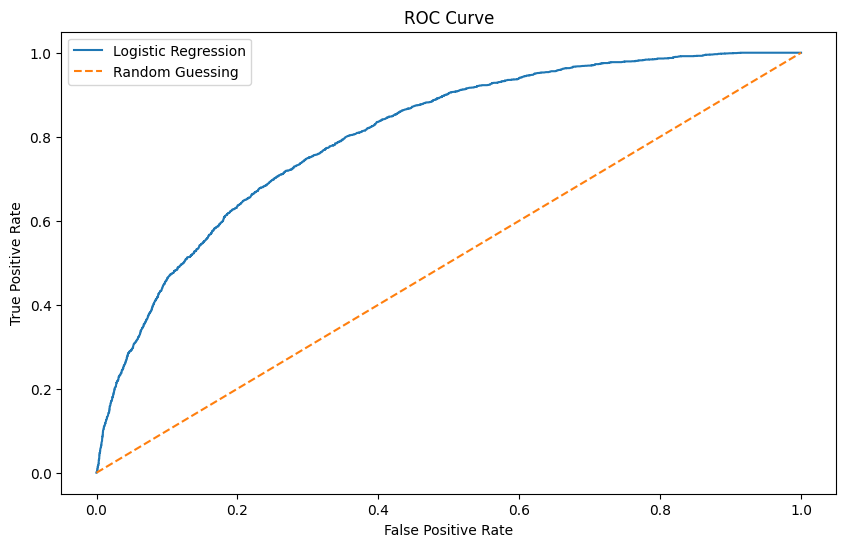

In [47]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label="Logistic Regression")
ax.plot([0,1], [0,1], linestyle="--", label="Random Guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.title("ROC Curve")
plt.show()

In [48]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,y_proba)
print(auc)

0.8033896337991391


In [49]:
for t in [0.3,0.4,0.5,0.6]:
    y_pred_t = (y_proba >= t).astype(int)
    recall = recall_score(y_test,y_pred_t)
    specificity = recall_score(y_test,y_pred_t,pos_label=0)
    print(f"Threshold={t}: Recall={recall:.3f}, Specificity={specificity:.3f}")

Threshold=0.3: Recall=0.638, Specificity=0.797
Threshold=0.4: Recall=0.479, Specificity=0.890
Threshold=0.5: Recall=0.339, Specificity=0.937
Threshold=0.6: Recall=0.229, Specificity=0.968


By computing the ROC-AUC score we make a better decision about which model is better, now we compute Precision-Recall curve to chose a better threshold

A Precision-Recall curve plots recall on the x-axis (of all the real positives, how many did we catch) and on the y-axis precision (of everything we predicted as positive, how many were actually positive), each point on hte curve represents one threshold.

In this case PR is more important than ROC.

ROC curve answers: How well can the model separate classes in general? The issue with this is that when classes are imbalanced, FPR can look small even when FP count is large

PR answers: When I act on a positive prediction, how much do I trust it and how much do I miss? This is important because positives in this case are rare and false negatives matter.

In [50]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_test, y_proba)

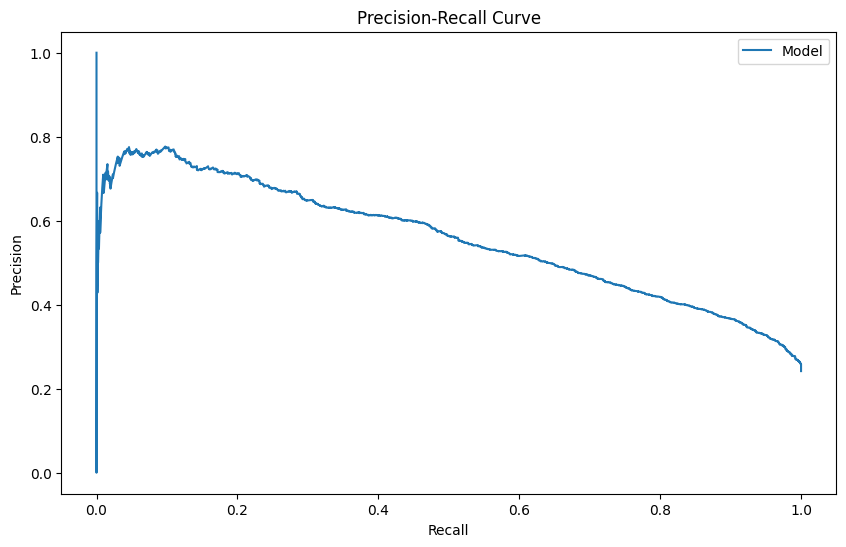

In [51]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(recall,precision,label="Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.title("Precision-Recall Curve")
ax.legend()
plt.show()

In [52]:
for t in [0.2,0.3,0.4,0.5]:
    y_pred_t = (y_proba >= t).astype(int)
    precision_t = precision_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t)

    print(f"Threshold: {t}: Precision={precision_t:.3f}, Recall={recall_t:.3f}")

Threshold: 0.2: Precision=0.417, Recall=0.802
Threshold: 0.3: Precision=0.501, Recall=0.638
Threshold: 0.4: Precision=0.582, Recall=0.479
Threshold: 0.5: Precision=0.631, Recall=0.339


In [53]:
low_threshold = (y_proba>=0.2).astype(int)

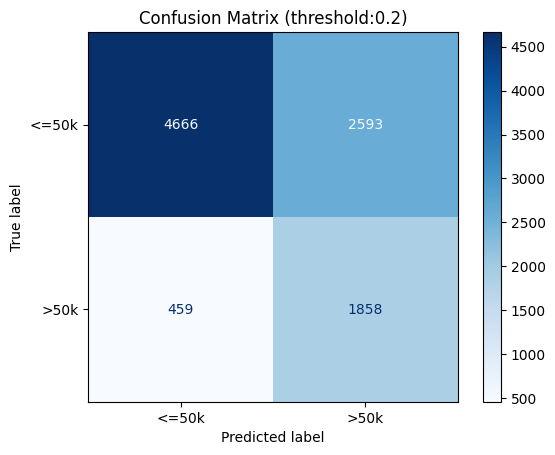

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,low_threshold,display_labels=['<=50k','>50k'],cmap='Blues')
plt.title("Confusion Matrix (threshold:0.2)")
plt.show()

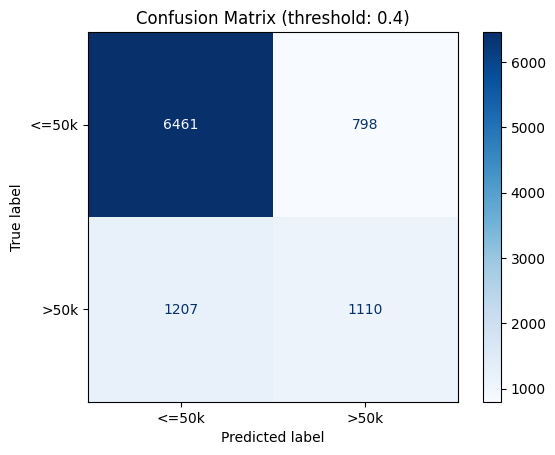

In [55]:
high_threshold = (y_proba>=0.4).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test,high_threshold,display_labels=['<=50k','>50k'],cmap='Blues')
plt.title("Confusion Matrix (threshold: 0.4)")
plt.show()

Comparing the two confusion matrices we can see that when we use a lower threshold we have:
1. less true negatives and less false negatives
2. more false positives and more true positives

## Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=23)
model_rf.fit(x_train,y_train)
model_rf.score(x_test,y_test)

0.7767335004177109

In [57]:
y_pred = model_rf.predict(x_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.5486677542142468
Recall: 0.4354769097971515
Specificity: 0.8856591817054691


Decision Tree metrics:
1. Precision: 0.5347852389594676
2. Recall: 0.3813632441760138
3. Specificity: 0.8940479470928631

In [58]:
def train_and_evaluate_model(x_train,x_test,y_train,y_test,n_estimators,max_depth):
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,random_state=23)
    model.fit(x_train,y_train)
    accuracy = model.score(x_test,y_test)
    y_pred = model.predict(x_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    specificity = recall_score(y_test, y_pred, pos_label=0)
    print(f'\nn_estimators: {n_estimators}, max_depth: {max_depth}')
    print(f'Accuracy: {accuracy:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')

In [59]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,10,None)


n_estimators: 10, max_depth: None
Accuracy: 0.774
Recall: 0.426
Specificity: 0.886


In [60]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,50,None)


n_estimators: 50, max_depth: None
Accuracy: 0.776
Recall: 0.430
Specificity: 0.887


In [61]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,100,None)


n_estimators: 100, max_depth: None
Accuracy: 0.777
Recall: 0.435
Specificity: 0.886


In [62]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,50,3)


n_estimators: 50, max_depth: 3
Accuracy: 0.760
Recall: 0.009
Specificity: 1.000


In [63]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,50,5)


n_estimators: 50, max_depth: 5
Accuracy: 0.774
Recall: 0.088
Specificity: 0.992


In [64]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,10,3)


n_estimators: 10, max_depth: 3
Accuracy: 0.761
Recall: 0.018
Specificity: 0.998


In [65]:
train_and_evaluate_model(x_train,x_test,y_train,y_test,100,3)


n_estimators: 100, max_depth: 3
Accuracy: 0.760
Recall: 0.009
Specificity: 1.000


In [66]:
feature_importances = pd.Series(model_rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print(feature_importances)

age                             0.565097
occupation_Exec-managerial      0.053610
education_Bachelors             0.047520
occupation_Prof-specialty       0.040385
education_Masters               0.035406
education_Prof-school           0.026485
occupation_Other-service        0.023076
workclass_Self-emp-inc          0.018116
education_HS-grad               0.017640
education_Doctorate             0.016841
workclass_Private               0.012909
education_Some-college          0.011944
workclass_Self-emp-not-inc      0.009997
occupation_Adm-clerical         0.009659
occupation_Sales                0.009529
workclass_Local-gov             0.008461
workclass_Federal-gov           0.007849
occupation_Craft-repair         0.007767
education_Assoc-voc             0.007665
education_Assoc-acdm            0.007366
workclass_State-gov             0.007286
occupation_Tech-support         0.006238
education_11th                  0.005917
occupation_Protective-serv      0.005725
occupation_Trans

### Comparing all the models and choosing the best one

#### Logistic Regression

Training the model

In [67]:
model_linear = LogisticRegression(max_iter=1000)
model_linear.fit(x_train,y_train)
model_linear.score(x_test,y_test)

0.7920843776106934

Precision-Recall curve

In [68]:
y_proba = model_linear.predict_proba(x_test)[:,1]

In [69]:
precision, recall, threshold = precision_recall_curve(y_test,y_proba)

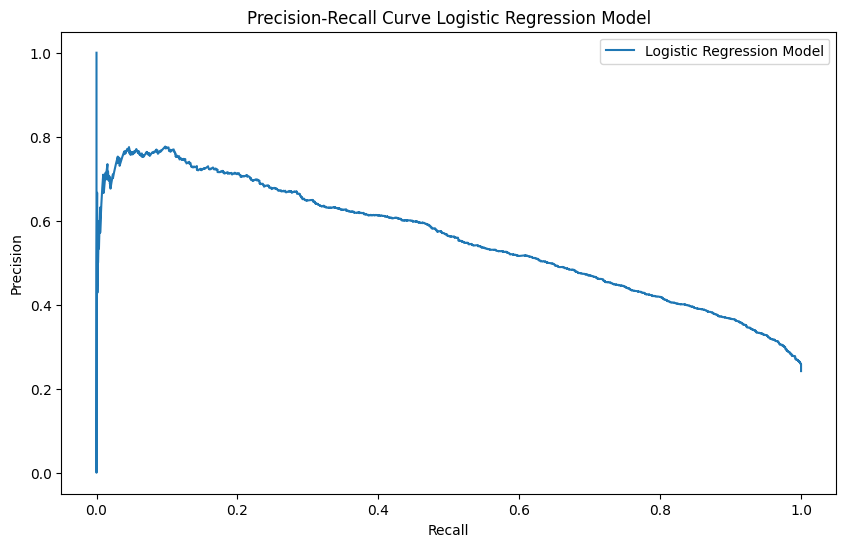

In [70]:
fig,ax = plt.subplots(figsize=(10,6))
ax.plot(recall,precision,label="Logistic Regression Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Logistic Regression Model")
ax.legend()
plt.show()

Choosing the best threshold

In [71]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45]:
    y_pred = (y_proba>=t).astype(int)
    recall = recall_score(y_test,y_pred)
    specificity = recall_score(y_test,y_pred, pos_label=0)
    print(f'\nThreshold: {t}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')


Threshold: 0.2
Recall: 0.802
Specificity: 0.643

Threshold: 0.25
Recall: 0.723
Specificity: 0.722

Threshold: 0.3
Recall: 0.638
Specificity: 0.797

Threshold: 0.35
Recall: 0.555
Specificity: 0.845

Threshold: 0.4
Recall: 0.479
Specificity: 0.890

Threshold: 0.45
Recall: 0.409
Specificity: 0.917


Best threshold 0.25, high recall while still mantaining a high specificity (most balanced tradeoff)

ROC-AUC Curve

In [72]:
fpr, tpr, threshold = roc_curve(y_test,y_proba)

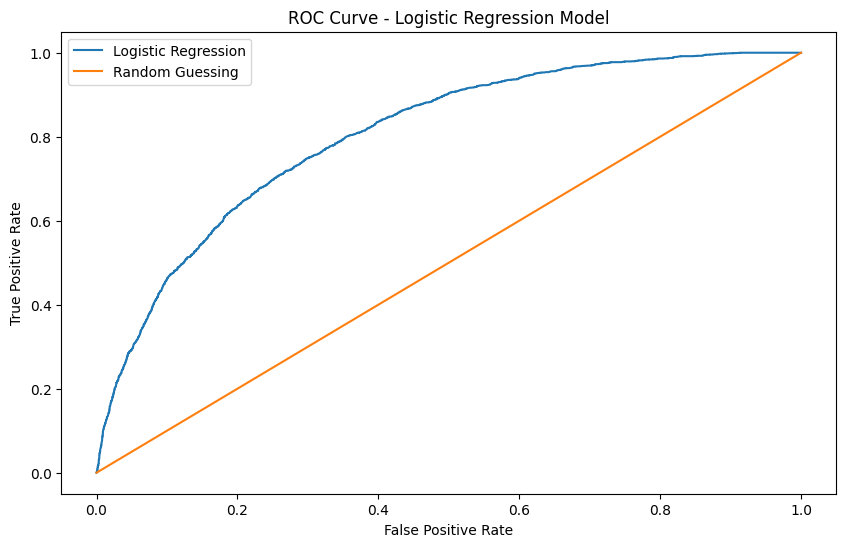

In [73]:
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label="Logistic Regression")
ax.plot([0,1],[0,1], label="Random Guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.set_title("ROC Curve - Logistic Regression Model")
plt.show()

In [74]:
auc = roc_auc_score(y_test,y_proba)
print(f'AUC Score for Logistic Regression Model: {auc:.3f}')

AUC Score for Logistic Regression Model: 0.803


#### Random Forest

Train the Model

In [75]:
model_forest = RandomForestClassifier(n_estimators=50)
model_forest.fit(x_train,y_train)
model_forest.score(x_test,y_test)

0.7777777777777778

In [76]:
y_proba_forest = model_forest.predict_proba(x_test)[:,1]

Precision-Recall Curve

In [77]:
precision, recall, threshold = precision_recall_curve(y_test,y_proba_forest)

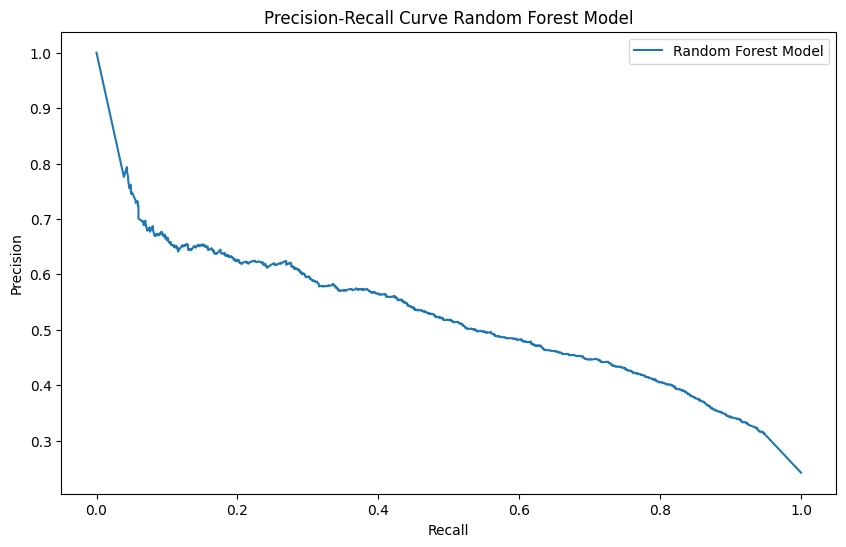

In [78]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(recall, precision, label="Random Forest Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Random Forest Model")
ax.legend()
plt.show()

Choosing the best threshold:

In [79]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45]:
    y_pred = (y_proba_forest >= t).astype(int)
    recall = recall_score(y_test,y_pred)
    specificity = recall_score(y_test,y_pred,pos_label=0)
    print(f'\nThreshold: {t}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')


Threshold: 0.2
Recall: 0.751
Specificity: 0.680

Threshold: 0.25
Recall: 0.693
Specificity: 0.727

Threshold: 0.3
Recall: 0.641
Specificity: 0.763

Threshold: 0.35
Recall: 0.596
Specificity: 0.797

Threshold: 0.4
Recall: 0.540
Specificity: 0.826

Threshold: 0.45
Recall: 0.479
Specificity: 0.863


ROC-AUC Curve

In [80]:
fpr, tpr, threshold = roc_curve(y_test, y_proba_forest)

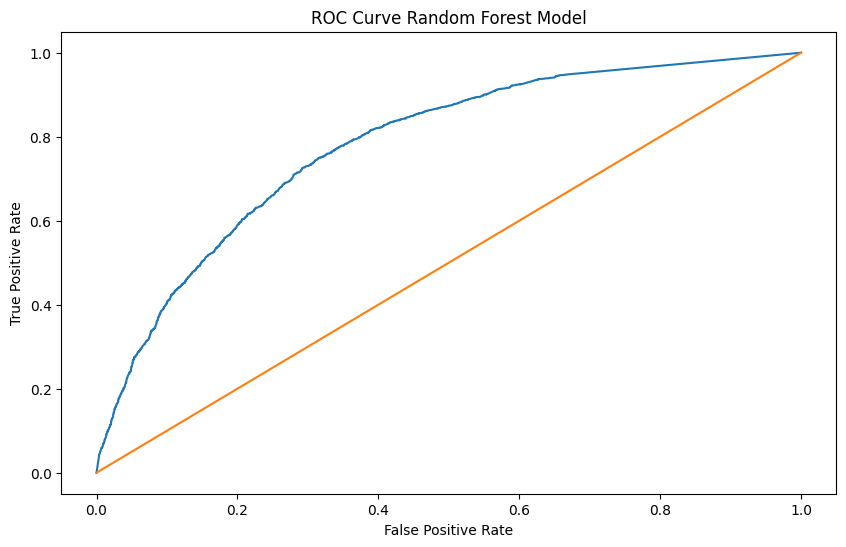

In [81]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label="Forest Model")
ax.plot([0,1],[0,1],label="Random Guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Random Forest Model")
plt.show()

In [82]:
auc = roc_auc_score(y_test,y_proba_forest)
print(f'ROC-AUC Score for Random Forest Model: {auc:.3f}')

ROC-AUC Score for Random Forest Model: 0.780


#### Balanced Random Forest

In [83]:
model_balanced_rf = RandomForestClassifier(class_weight='balanced')
model_balanced_rf.fit(x_train,y_train)
model_balanced_rf.score(x_test,y_test)

0.7387218045112782

In [84]:
y_proba_rf_balanced = model_balanced_rf.predict_proba(x_test)[:,1]

In [85]:
precision, recall, threshold = precision_recall_curve(y_test,y_proba_rf_balanced)

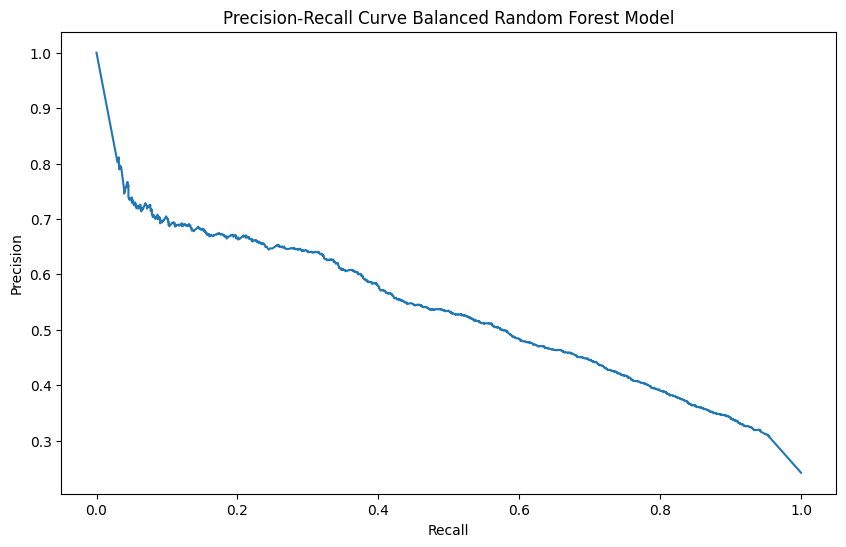

In [86]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(recall,precision,label="Balanced Random Forest Classifier Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Balanced Random Forest Model")
plt.show()

In [87]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45]:
    y_pred = (y_proba_rf_balanced>=t).astype(int)
    recall = recall_score(y_test,y_pred)
    specificity = recall_score(y_test,y_pred,pos_label=0)
    print(f'\nThreshold: {t}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')


Threshold: 0.2
Recall: 0.835
Specificity: 0.549

Threshold: 0.25
Recall: 0.808
Specificity: 0.593

Threshold: 0.3
Recall: 0.777
Specificity: 0.632

Threshold: 0.35
Recall: 0.749
Specificity: 0.667

Threshold: 0.4
Recall: 0.723
Specificity: 0.694

Threshold: 0.45
Recall: 0.688
Specificity: 0.732


ROC Curve

In [88]:
fpr, tpr, threshold = roc_curve(y_test,y_proba_rf_balanced)

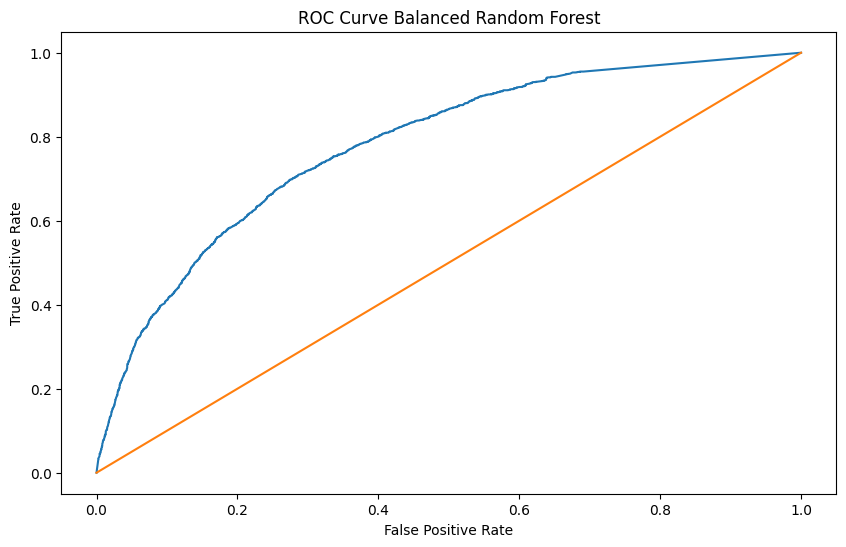

In [89]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label="Balanced Random Forest")
ax.plot([0,1],[0,1],label="Random Guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Balanced Random Forest")
plt.show()

In [92]:
auc = roc_auc_score(y_test,y_proba_rf_balanced)
print(f'ROC-AUC Score Balanced Random Forest: {auc:.3f}')

ROC-AUC Score Balanced Random Forest: 0.780


#### Conclustion

The best model is logistic regression with the threshold of 0.25

In [ ]:
y_pred = (y_proba>=0.25).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['<=50k','>50k'],cmap='Blues')
plt.title("Confusion Matrix Logisitc Regression Model with threshold 0.25")
plt.show()

1. 5224 people were correctly classified as having a salary lower than 50k
2. 633 people were incorrectly classified as having a salary lower than 50k
3. 2007 people were incorrectly classified as having a salary higher than 50k
4. 1712 people were correctly classified as having a salary higher than 50k

#### Gradient Boosting

In [93]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=0)
model_gb.fit(x_train,y_train)
model_gb.score(x_test,y_test)

0.8037802840434419

In [94]:
y_proba = model_gb.predict_proba(x_test)[:,1]

In [96]:
precision, recall, threshold = precision_recall_curve(y_test, y_proba)

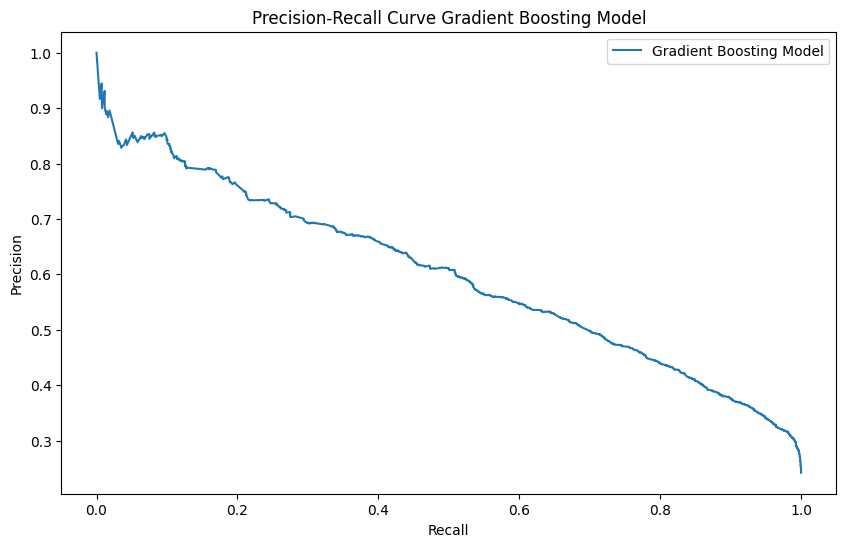

In [99]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(recall, precision, label='Gradient Boosting Model')
ax.legend()
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Gradient Boosting Model')
plt.show()

In [100]:
fpr, tpr, threshold = roc_curve(y_test, y_proba)

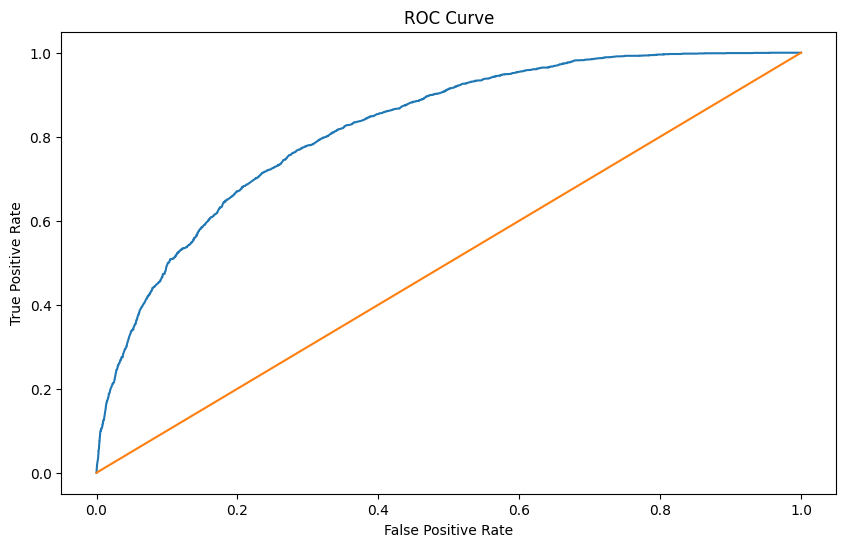

In [102]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label='Gradient Boosting Model')
ax.plot([0,1],[0,1], label='Random Guessing')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
plt.show()

In [103]:
auc = roc_auc_score(y_test,y_proba)
print(f'ROC-AUC score for Gradient Boosting Model: {auc:.3f}')

ROC-AUC score for Gradient Boosting Model: 0.822


In [106]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45,0.5]:
    y_pred = (y_proba>=t).astype(int)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    specificity = recall_score(y_test,y_pred,pos_label=0)
    print(f'\nPrecision for threshold {t}: {precision:.3f}')
    print(f'Recall for threshold {t}: {recall:.3f}')
    print(f'Specificity for threshold {t}: {specificity:.3f}')


Precision for threshold 0.2: 0.422
Recall for threshold 0.2: 0.832
Specificity for threshold 0.2: 0.636

Precision for threshold 0.25: 0.467
Recall for threshold 0.25: 0.757
Specificity for threshold 0.25: 0.724

Precision for threshold 0.3: 0.516
Recall for threshold 0.3: 0.671
Specificity for threshold 0.3: 0.799

Precision for threshold 0.35: 0.560
Recall for threshold 0.35: 0.566
Specificity for threshold 0.35: 0.858

Precision for threshold 0.4: 0.604
Recall for threshold 0.4: 0.508
Specificity for threshold 0.4: 0.894

Precision for threshold 0.45: 0.640
Recall for threshold 0.45: 0.432
Specificity for threshold 0.45: 0.922

Precision for threshold 0.5: 0.670
Recall for threshold 0.5: 0.372
Specificity for threshold 0.5: 0.942


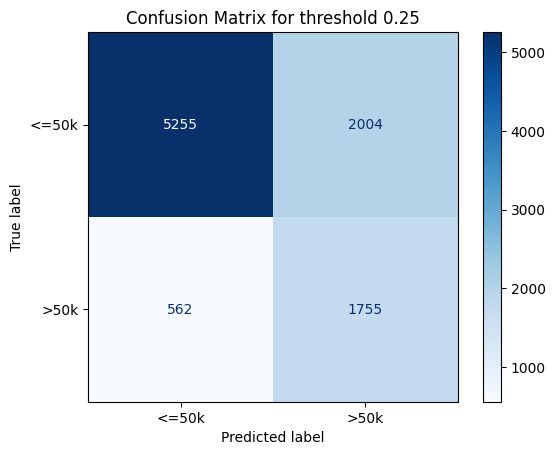

In [114]:
y_pred = (y_proba>=0.25).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['<=50k','>50k'],cmap='Blues')
plt.title('Confusion Matrix for threshold 0.25')
plt.show()

1. 5255 people were correctly classified as having a salary lower than 50k
2. 562 people were incorrectly classified as having a salary lower than 50k
3. 2004 people were incorrectly classified as having a salary higher than 50k
4. 1755 people were correctly classified as having a salary higher than 50k

In [115]:
gb = GradientBoostingClassifier(random_state=23)
param_dist = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.01,0.05,0.1],
    'max_depth': [2,3,4],
    'subsample': [0.7,0.8,1.0]
}

In [120]:
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    scoring='roc_auc',
    cv=5,
    random_state=23,
    n_jobs=-1
)
search.fit(x_train,y_train)

,estimator,GradientBoost...ndom_state=23)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.7, 0.8, ...]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,23
,error_score,nan


In [121]:
best_gb = search.best_estimator_
print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.1}
0.8272677914158756


In [122]:
y_proba_gb = best_gb.predict_proba(x_test)[:,1]
test_auc = roc_auc_score(y_test,y_proba_gb)
print(f'Test ROC-AUC: {test_auc:.3f}')

Test ROC-AUC: 0.827


In [124]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45,0.5]:
    y_pred = (y_proba_gb>=t).astype(int)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    specificity = recall_score(y_test,y_pred,pos_label=0)
    print(f'\nThreshold: {t}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')


Threshold: 0.2
Precision: 0.433
Recall: 0.819
Specificity: 0.658

Threshold: 0.25
Precision: 0.468
Recall: 0.764
Specificity: 0.723

Threshold: 0.3
Precision: 0.506
Recall: 0.695
Specificity: 0.784

Threshold: 0.35
Precision: 0.550
Recall: 0.612
Specificity: 0.840

Threshold: 0.4
Precision: 0.594
Recall: 0.529
Specificity: 0.884

Threshold: 0.45
Precision: 0.637
Recall: 0.452
Specificity: 0.918

Threshold: 0.5
Precision: 0.669
Recall: 0.394
Specificity: 0.938


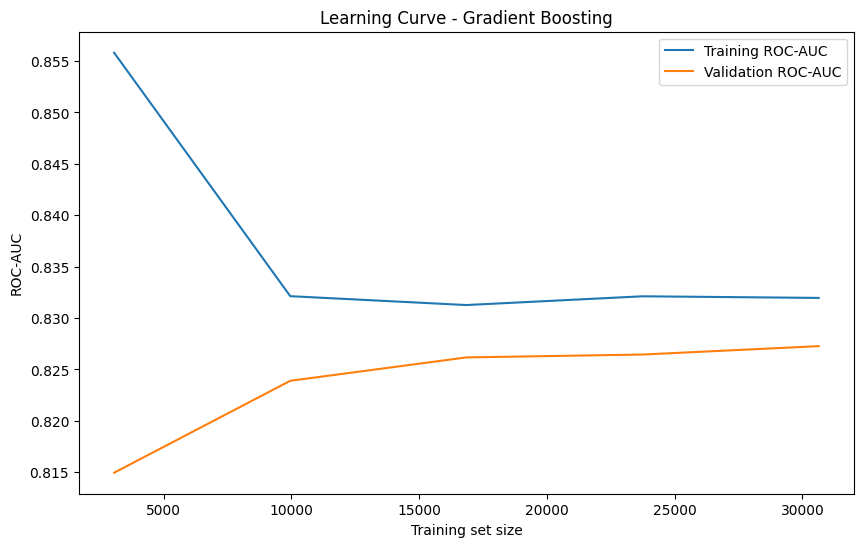

In [127]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_gb,
    x_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=5
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label='Training ROC-AUC')
plt.plot(train_sizes, val_mean, label='Validation ROC-AUC')
plt.xlabel('Training set size')
plt.ylabel('ROC-AUC')
plt.title('Learning Curve - Gradient Boosting')
plt.legend()
plt.show()

In [128]:
importances = pd.Series(best_gb.feature_importances_,index=x_train.columns).sort_values(ascending=False)
importances.head(10)

age                           0.388287
occupation_Exec-managerial    0.103595
education_Bachelors           0.096078
occupation_Prof-specialty     0.080293
education_Masters             0.061188
education_Prof-school         0.060207
occupation_Other-service      0.049101
education_Doctorate           0.037166
workclass_Self-emp-inc        0.024595
occupation_Sales              0.013624
dtype: float64

In [130]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_gb,
    x_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=23
)

perm_importances = pd.Series(perm.importances_mean,index=x_test.columns).sort_values(ascending=False)

perm_importances.head(10)

age                           0.155374
education_Bachelors           0.025684
occupation_Exec-managerial    0.014895
occupation_Other-service      0.012768
education_Masters             0.011290
education_Prof-school         0.010497
education_Doctorate           0.007783
occupation_Prof-specialty     0.006717
workclass_Self-emp-inc        0.004616
occupation_Sales              0.003563
dtype: float64

#### Calibration

In [131]:
x_train_cal, x_cal, y_train_cal, y_cal = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=23
)

In [132]:
gb = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=300,
    max_depth=2,
    learning_rate=0.1,
    random_state=23
)

gb.fit(x_train_cal, y_train_cal)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [133]:
y_cal_proba = gb.predict_proba(x_cal)[:,1]
y_test_proba = gb.predict_proba(x_test)[:,1]

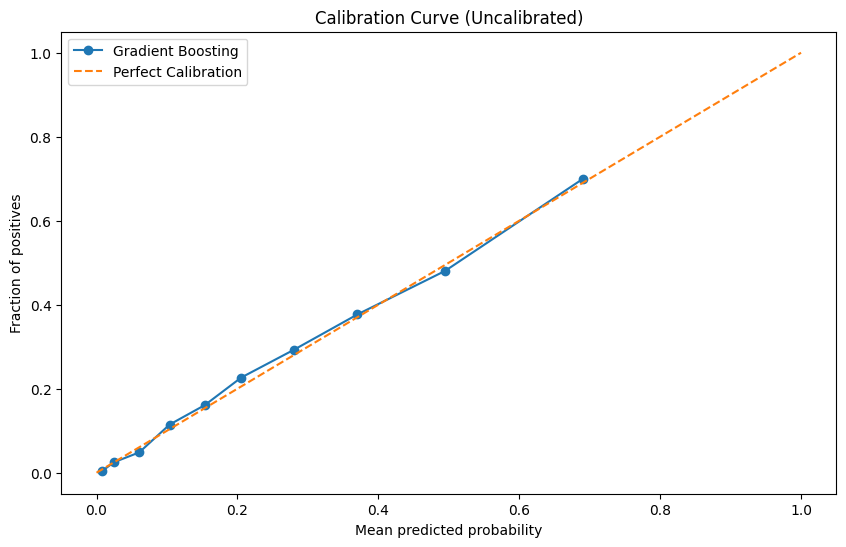

In [134]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_cal,y_cal_proba,n_bins=10,strategy='quantile')
plt.figure(figsize=(10,6))
plt.plot(prob_pred, prob_true, marker='o', label='Gradient Boosting')
plt.plot([0,1],[0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (Uncalibrated)')
plt.legend()
plt.show()

In [135]:
from sklearn.metrics import brier_score_loss

brier_uncal = brier_score_loss(y_cal, y_cal_proba)
print(f'Brier score (uncalibrated): {brier_uncal:.4f}')

Brier score (uncalibrated): 0.1379


In [136]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_gb = CalibratedClassifierCV(
    estimator=best_gb,
    method='sigmoid',
    cv='prefit'
)

calibrated_gb.fit(x_cal,y_cal)

/home/nb/Projects/AppliedML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,GradientBoost...subsample=0.8)
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,loss,'log_loss'
,learning_rate,0.1
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2


In [137]:
y_test_proba_cal = calibrated_gb.predict_proba(x_test)[:,1]

In [138]:
auc_uncal = roc_auc_score(y_test, y_test_proba)
auc_cal = roc_auc_score(y_test, y_test_proba_cal)

print(f'Uncalibrated ROC-AUC: {auc_uncal:.3f}')
print(f'Calibrated ROC-AUC: {auc_cal:.3f}')

Uncalibrated ROC-AUC: 0.826
Calibrated ROC-AUC: 0.827


In [139]:
brier_cal = brier_score_loss(y_test, y_test_proba_cal)

print(f'Brier (uncalibrated): {brier_uncal:.4f}')
print(f'Brier (calibrated): {brier_cal:.4f}')

Brier (uncalibrated): 0.1379
Brier (calibrated): 0.1351


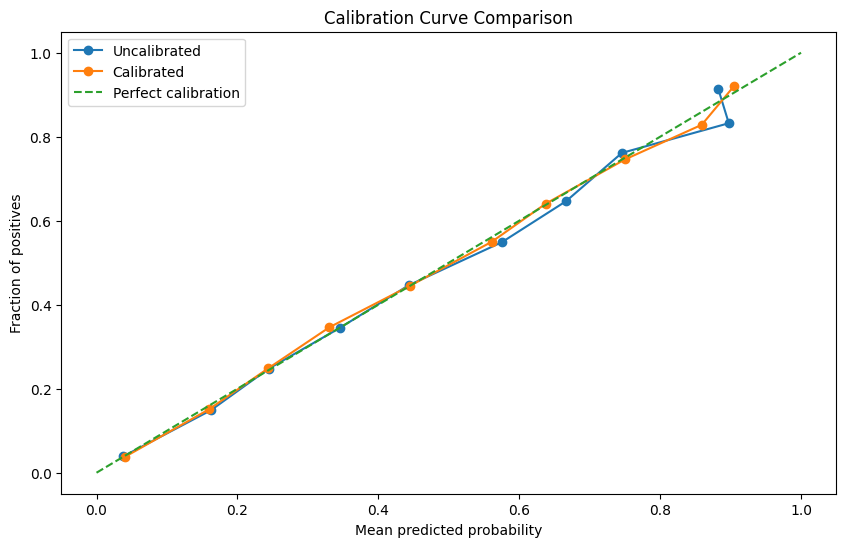

In [140]:
prob_uncal, frac_uncal = calibration_curve(y_test, y_test_proba, n_bins=10)
prob_cal, frac_cal = calibration_curve(y_test, y_test_proba_cal, n_bins=10)

plt.figure(figsize=(10,6))
plt.plot(prob_uncal, frac_uncal, marker='o', label='Uncalibrated')
plt.plot(prob_cal, frac_cal, marker='o', label='Calibrated')
plt.plot([0,1],[0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve Comparison')
plt.legend()
plt.show()

In [141]:
for t in [0.2,0.25,0.3,0.35,0.4,0.45]:
    y_pred_cal = (y_test_proba_cal >= t).astype(int)
    precision = precision_score(y_test, y_pred_cal)
    recall = recall_score(y_test, y_pred_cal)
    specificity = recall_score(y_test, y_pred_cal, pos_label=0)

    print(f'\nThreshold: {t}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'Specificity: {specificity:.3f}')


Threshold: 0.2
Precision: 0.435
Recall: 0.818
Specificity: 0.660

Threshold: 0.25
Precision: 0.468
Recall: 0.764
Specificity: 0.723

Threshold: 0.3
Precision: 0.501
Recall: 0.700
Specificity: 0.778

Threshold: 0.35
Precision: 0.544
Recall: 0.621
Specificity: 0.834

Threshold: 0.4
Precision: 0.588
Recall: 0.544
Specificity: 0.878

Threshold: 0.45
Precision: 0.626
Recall: 0.466
Specificity: 0.911


In [143]:
calibrated_iso = CalibratedClassifierCV(
    estimator=best_gb,
    method='isotonic',
    cv='prefit',
)

calibrated_iso.fit(x_cal,y_cal)
y_test_proba_iso = calibrated_iso.predict_proba(x_test)[:,1]

/home/nb/Projects/AppliedML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [145]:
auc_iso = roc_auc_score(y_test, y_test_proba_iso)
print(f'Isotonic ROC-AUC: {auc_iso:.3f}')

Isotonic ROC-AUC: 0.826


In [147]:
brier_iso = brier_score_loss(y_test, y_test_proba_iso)
print(f'Brier (isotonic): {brier_iso:.4f}')

Brier (isotonic): 0.1353


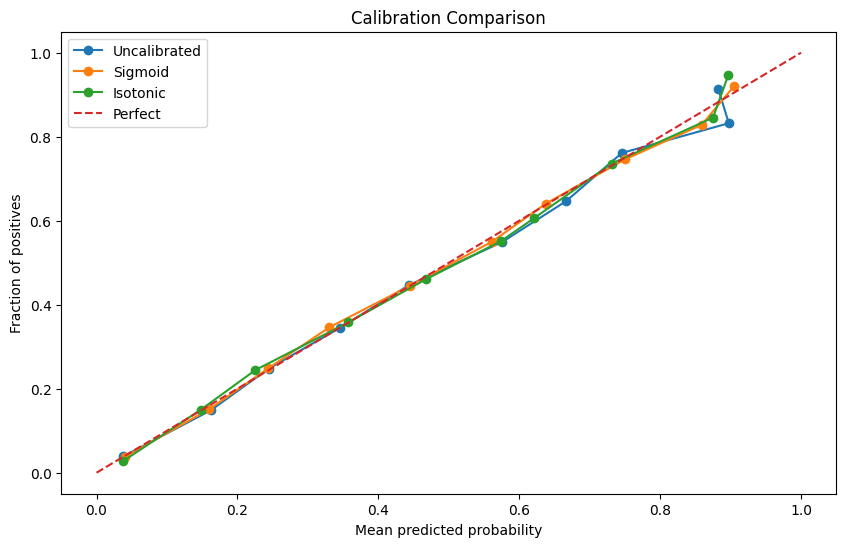

In [150]:
proba_iso, frac_iso = calibration_curve(y_test, y_test_proba_iso, n_bins=10)

plt.figure(figsize=(10,6))
plt.plot(prob_uncal, frac_uncal, marker='o', label='Uncalibrated')
plt.plot(prob_cal, frac_cal, marker='o', label='Sigmoid')
plt.plot(proba_iso, frac_iso, marker='o', label='Isotonic')
plt.plot([0,1],[0,1],'--', label='Perfect')
plt.legend()
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Comparison')
plt.show()

# Why is GB the best choice?
1. Highest ROC-AUC score - If we randomly pick a >50k and <=50k person from the dataset the model assigns higher probability to the >50k person 82.7% of the time, this indicates superior class discrimination
2. Achieves strong recall without destroying specificity
3. Calibration is stabel - Brier improved slightly, ROC-AUC didn't change which means the model is already well-behaved and calibration didn't break discrimination
4. Bias-Variance tradeoff is well controled - Training ROC-AUC is not extremely higher than validation, the curves converge and there is no huge variance gap

In [155]:
final_gb = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=300,
    max_depth=2,
    learning_rate=0.1,
    random_state=23,
)

final_gb.fit(x_train,y_train)

final_model = CalibratedClassifierCV(
    estimator=final_gb,
    method='sigmoid',
    cv=5
)

final_model.fit(x_train,y_train)

,estimator,GradientBoost...subsample=0.8)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,loss,'log_loss'
,learning_rate,0.1
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2


In [156]:
FINAL_THRESHOLD = 0.25

In [157]:
def predict_with_threshold(model, X, threshold):
    proba = model.predict_proba(X)[:,1]
    return (proba >= threshold).astype(int)

In [158]:
y_test_proba_final = final_model.predict_proba(x_test)[:,1]
y_test_pred_final = (y_test_proba_final>=FINAL_THRESHOLD).astype(int)

print('Final ROC-AUC:', roc_auc_score(y_test, y_test_pred_final))
print('Final Precision:', precision_score(y_test, y_test_pred_final))
print('Final Recall:', recall_score(y_test, y_test_pred_final))

Final ROC-AUC: 0.7435707480951868
Final Precision: 0.4723942903312685
Final Recall: 0.7570133793698748


In [160]:
import joblib

joblib.dump({
    "model": final_model,
    "threshold": FINAL_THRESHOLD,
}, "income_Classifier.pkl")

['income_Classifier.pkl']

## Project Summary

Income Classification Model (Adult Income Dataset)

1. Built and compared Logistic Regression, Random Forest, and Gradient Boosting models
2. Performed hyperparameter tuning using cross-validated RandomizedSearch
3. Evaluated models using ROC-AUC, precision-recall tradeoffs, and confusion matrices
4. Analyzed bias-variance behavior with learning curves
5. Assessed feature importance using impurity-based and permutation methods
6. Evaluated and improved probability calibration using Platt scaling (Brier score reduction)
7. Selected tuned Gradient Boosting model, and deployed with calibrated probability threshold of 0.25
8. Saved final production-ready model using joblib